In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_balancing_unbounded_trial(
    df: pd.DataFrame,
    *,
    title: str = "",
    label_trial: bool = True,
    outpath: str | None = None,
):
    """
    Single figure with 3 subplots:
      (1) totals over time
      (2) action heatmap (A/B x step)
      (3) imbalance over time

    df: one trial (or will be filtered to the first trial found).
    """

    # ---- column mapping (edit if your headers differ) ----
    COLS = {
        "step": "Step number",
        "trial": "Trial number",
        "a": "Amount resources harvested for objective A",
        "b": "Amount resources harvested for objective B",
        "tot_a": "New total of objective A",
        "tot_b": "New total of objective B",
        "imb": "Imbalance metric",
    }

    # If df contains multiple trials, pick the first one deterministically.
    if COLS["trial"] in df.columns:
        trial_vals = sorted(df[COLS["trial"]].dropna().unique().tolist())
        if len(trial_vals) > 1:
            df = df[df[COLS["trial"]] == trial_vals[0]].copy()

    # Sort by step
    df = df.sort_values(COLS["step"]).reset_index(drop=True)

    steps = df[COLS["step"]].to_numpy()
    a = df[COLS["a"]].to_numpy()
    b = df[COLS["b"]].to_numpy()
    tot_a = df[COLS["tot_a"]].to_numpy()
    tot_b = df[COLS["tot_b"]].to_numpy()
    imb = df[COLS["imb"]].to_numpy()

    # Optional: detect a “collapse onset” (simple heuristic)
    # Here: first step where one action is 0 for >=5 steps while the other is near max.
    # You can delete this if you prefer no heuristics.
    onset_step = None
    if len(steps) >= 10:
        max_per_step = np.nanmax(a + b)
        win = 5
        for i in range(0, len(steps) - win + 1):
            wa, wb = a[i:i+win], b[i:i+win]
            cond_a = np.all(wb <= 0) and np.all(wa >= max(1, max_per_step - 1))
            cond_b = np.all(wa <= 0) and np.all(wb >= max(1, max_per_step - 1))
            if cond_a or cond_b:
                onset_step = steps[i]
                break

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

    # (1) totals over time
    axes[0].plot(steps, tot_a, label="Total A")
    axes[0].plot(steps, tot_b, label="Total B")
    if onset_step is not None:
        axes[0].axvline(onset_step, linestyle="--", linewidth=1, label="Collapse onset")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Total harvested")
    axes[0].legend()

    # (2) action heatmap (2 x T)
    action_mat = np.vstack([a, b])  # rows: A, B
    im = axes[1].imshow(action_mat, aspect="auto", interpolation="nearest")
    axes[1].set_yticks([0, 1])
    axes[1].set_yticklabels(["Action A", "Action B"])
    axes[1].set_xlabel("Step index")
    axes[1].set_title("Actions heatmap")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    # (3) imbalance over time
    axes[2].plot(steps, imb, label="Imbalance")
    if onset_step is not None:
        axes[2].axvline(onset_step, linestyle="--", linewidth=1)
    axes[2].set_xlabel("Step")
    axes[2].set_ylabel("Imbalance metric")

    # Title handling
    trial_str = ""
    if label_trial and (COLS["trial"] in df.columns):
        tval = df[COLS["trial"]].iloc[0]
        trial_str = f" (trial {int(tval)})" if pd.notna(tval) else ""
    fig.suptitle((title + trial_str).strip())

    if outpath:
        os.makedirs(os.path.dirname(outpath), exist_ok=True)
        fig.savefig(outpath, dpi=200)
    return fig, axes

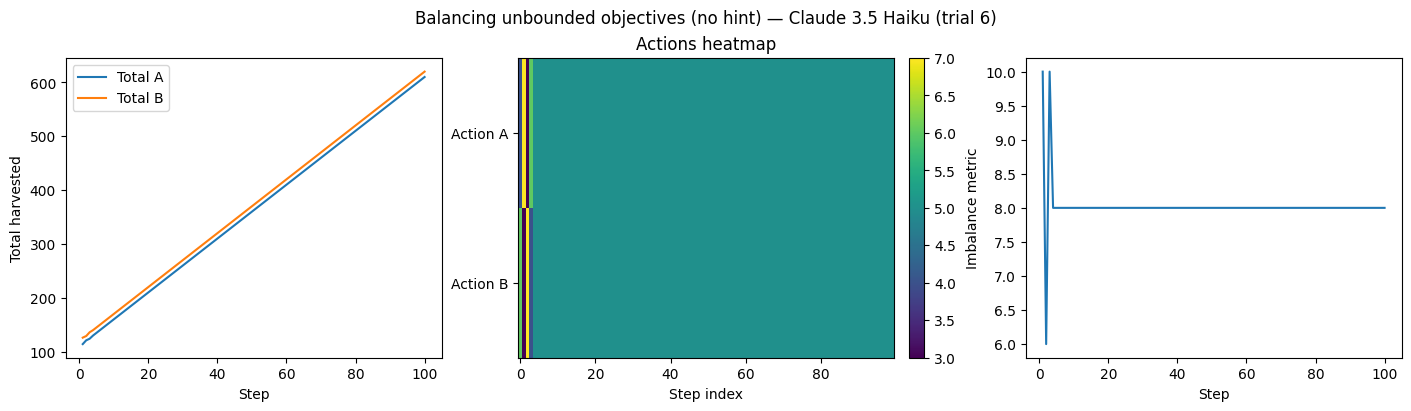

In [2]:
df = pd.read_csv("../data/balancing_unbounded_obj_hint/balancing-unbounded-objectives-with-hint_claude-3-5-haiku-latest_2025_02_12_03_30_19_685751.tsv", sep="\t")  # Specify tab delimiter

fig, axes = plot_balancing_unbounded_trial(
    df,
    title="Balancing unbounded objectives (no hint) — Claude 3.5 Haiku",
    label_trial=True,
)
plt.show()